### What are Embeddings?

Embeddings are ways of converting texts into numbers called vectors that a model can understand


In [3]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


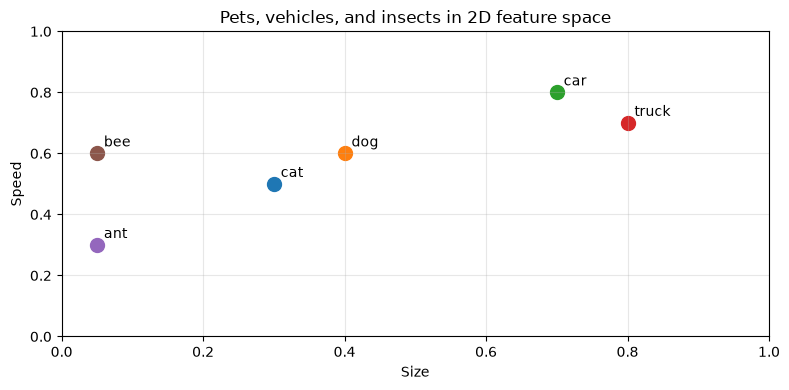

In [19]:
# simplified 2D example (real embeddings may have hundreds of dimensions)
# Illustrative only — real dimensions aren't labeled like this.
# Assume these hypothetical features for teaching purposes:

# features - [size, speed]
word_embeddings_2d = {
    "cat":   [0.3, 0.5],
    "dog":   [0.4, 0.6],
    "car":   [0.7, 0.8],
    "truck": [0.8, 0.7],
    "ant":   [0.05, 0.3],
    "bee":   [0.05, 0.6],
}
fig, ax = plt.subplots(figsize=(8, 4))

for word, coords in word_embeddings_2d.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5, 5),
                textcoords='offset points')
ax.set_xlabel('Size')
ax.set_ylabel('Speed')
ax.set_title('Pets, vehicles, and insects in 2D feature space')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

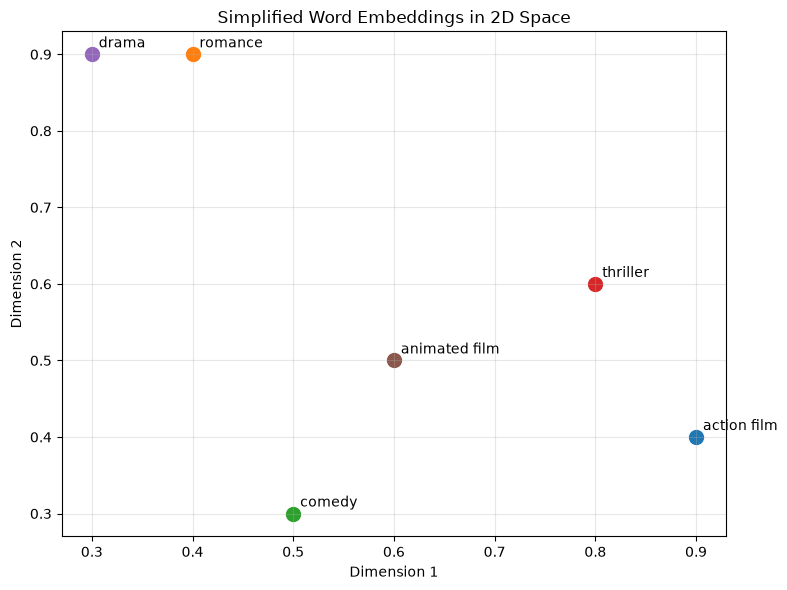

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5, 5), 
                textcoords='offset points')

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

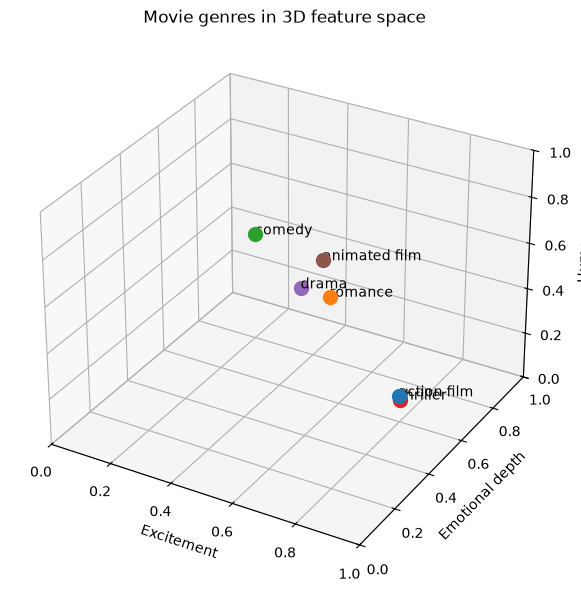

In [23]:

# features - [excitement, emotional_depth, humor]
word_embeddings_3d = {
    "action film":   [0.9, 0.4, 0.3],
    "romance":       [0.4, 0.9, 0.2],
    "comedy":        [0.5, 0.3, 0.9],
    "thriller":      [0.8, 0.6, 0.1],
    "drama":         [0.3, 0.9, 0.2],
    "animated film": [0.6, 0.5, 0.7],
}

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')

for word, coords in word_embeddings_3d.items():
    ax.scatter(coords[0], coords[1], coords[2], s=100)
    ax.text(coords[0], coords[1], coords[2], word)

ax.set_xlabel('Excitement')
ax.set_ylabel('Emotional depth')
ax.set_zlabel('Humor')
ax.set_title('Movie genres in 3D feature space')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)

plt.tight_layout()
plt.show()

### Measuring Similarity

Using cosine similarity:

$$\text{similarity} = \frac{A \cdot B}{\|A\| \times \|B\|}$$

In [ ]:
def cosine_similarity(v1, v2):
    """
        Measures the angle between two vectors
    
         1: Vectors point in the exact same direction (perfect similarity)
         0: Vectors are perpendicular (completely unrelated)
        -1: Vectors point in opposite directions (perfect dissimilarity)
        
    """
    
    dot_prod = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    
    
    return dot_prod / (norm_v1 * norm_v2)


In [39]:
word_embeddings = {
    "cat":   [0.3, 0.5],
    "dog":   [0.4, 0.6],
    "car":   [0.7, 0.8],
    "truck": [0.8, 0.7],
    "ant":   [0.05, 0.3],
    "bee":   [0.05, 0.6],
}

cat_dog = cosine_similarity(word_embeddings["cat"], word_embeddings["dog"])
car_truck = cosine_similarity(word_embeddings["car"], word_embeddings["truck"])
ant_bee = cosine_similarity(word_embeddings["ant"], word_embeddings["bee"])
ant_truck = cosine_similarity(word_embeddings["ant"], word_embeddings["truck"])

print(f"Cat and Dog Similarities: {cat_dog}")
print(f"Car and Truck Similarities: {car_truck}")
print(f"Ant and Bee Similarities: {ant_bee}")
print(f"Ant and Truck Similarities: {ant_truck}")

Cat and Dog Similarities: 0.9988681377244376
Car and Truck Similarities: 0.9911504424778759
Ant and Bee Similarities: 0.996639273541688
Ant and Truck Similarities: 0.7732677904963986


In [1]:
from langchain_huggingface import HuggingFaceEmbeddings

In [4]:

embeddings = HuggingFaceEmbeddings(
    model_name="all-minilm-l6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2254.10it/s]


In [10]:
query = "Allow for query"

embedding = embeddings.embed_query(query) 
print(f"Query  : {query}")
print(f"Length : {len(embedding)}")
(embedding)


Query  : Allow for query
Length : 384


[0.03442680835723877,
 0.06464822590351105,
 -0.02037127874791622,
 0.010557555593550205,
 -0.05929521843791008,
 0.06001100316643715,
 0.076246477663517,
 -0.02272348292171955,
 -0.060845889151096344,
 -0.04145308583974838,
 0.00010978401405736804,
 -0.02464667707681656,
 0.08489279448986053,
 -0.009404423646628857,
 -0.010133054107427597,
 0.046182695776224136,
 0.08818696439266205,
 -0.02892054244875908,
 -0.07140128314495087,
 -0.020048486068844795,
 0.05980952829122543,
 0.05336489528417587,
 -0.04246038571000099,
 0.007554643787443638,
 -0.07181043177843094,
 -0.04165171831846237,
 -0.03642527014017105,
 -0.05907636880874634,
 0.07659196108579636,
 0.007984357886016369,
 -0.06268668174743652,
 -0.020672231912612915,
 -0.028059450909495354,
 0.06760630756616592,
 0.01229559164494276,
 -0.09683575481176376,
 0.03257002308964729,
 -0.05744154751300812,
 -0.0340033583343029,
 -0.07797067612409592,
 -0.04841494932770729,
 -0.03938893601298332,
 0.015642274171113968,
 -0.01534249633550

In [20]:
sentences = [
    "Tell me about love",
    "I can't do without love cause I'm an emotional being",
    "Let's play football cause it's good for the soul",
    "Thanks for joining"
]

embedding_sents = embeddings.embed_documents(sentences)
print(f"Length {len(embedding_sents)}")
print(f"Length {(embedding_sents[0])}")
print(f"Length {(embedding_sents[1])}")
embedding_sents

Length 4
Length [-0.09385176748037338, 0.07260774821043015, 0.07138585299253464, 0.015033744275569916, 0.047889817506074905, 0.07697590440511703, 0.13193753361701965, 0.006245079915970564, 0.10210207849740982, 0.007834632880985737, -0.010940113104879856, -0.05456121638417244, 0.014710790477693081, -0.013844271190464497, 0.0019070249982178211, -0.03344620391726494, 0.022309157997369766, -0.05022513121366501, -0.1281256377696991, 0.033409204334020615, -0.023621609434485435, -0.002595491474494338, -0.09280126541852951, -0.00039659294998273253, -0.08737507462501526, 0.06392627209424973, 0.026897819712758064, -0.0027766949497163296, -0.037453390657901764, 0.022946728393435478, 0.08728642016649246, 0.008826559409499168, 0.0786992609500885, 0.02486388012766838, -0.06880047172307968, 0.050592951476573944, -0.012839236296713352, 0.04525145888328552, 0.01431052852421999, -0.06297241151332855, -0.0214209146797657, -0.07029515504837036, 0.02670971304178238, 0.051624685525894165, -0.002019721549004

[[-0.09385176748037338,
  0.07260774821043015,
  0.07138585299253464,
  0.015033744275569916,
  0.047889817506074905,
  0.07697590440511703,
  0.13193753361701965,
  0.006245079915970564,
  0.10210207849740982,
  0.007834632880985737,
  -0.010940113104879856,
  -0.05456121638417244,
  0.014710790477693081,
  -0.013844271190464497,
  0.0019070249982178211,
  -0.03344620391726494,
  0.022309157997369766,
  -0.05022513121366501,
  -0.1281256377696991,
  0.033409204334020615,
  -0.023621609434485435,
  -0.002595491474494338,
  -0.09280126541852951,
  -0.00039659294998273253,
  -0.08737507462501526,
  0.06392627209424973,
  0.026897819712758064,
  -0.0027766949497163296,
  -0.037453390657901764,
  0.022946728393435478,
  0.08728642016649246,
  0.008826559409499168,
  0.0786992609500885,
  0.02486388012766838,
  -0.06880047172307968,
  0.050592951476573944,
  -0.012839236296713352,
  0.04525145888328552,
  0.01431052852421999,
  -0.06297241151332855,
  -0.0214209146797657,
  -0.0702951550483

### Popular models comparison

#### all-MiniLM-L6-v2
- size: 384
- description: Fast and efficient, good quality
- use_case: General purpose, real-time applications

#### all-mpnet-base-v2
- size: 768
- description: Best quality, slower than MiniLM
- use_case: When quality matters more than speed

#### all-MiniLM-L12-v2
- size: 384
- description: Slightly better than L6, bit slower
- use_case: Good balance of speed and quality

#### multi-qa-MiniLM-L6-cos-v1
- size: 384
- description: Optimized for question-answering
- use_case: Q&A systems, semantic search

#### paraphrase-multilingual-MiniLM-L12-v2
- size: 384
- description: Supports 50+ languages
- use_case: Multilingual applications

